In [1]:
!pip install "numpy<2"

In [2]:
import sklearn
print(sklearn.__version__)

/home/codespace/anaconda3/lib/python3.9/site-packages/scipy/__init__.py:146: UserWarning: A NumPy version >=1.16.5 and <1.23.0 is required for this version of SciPy (detected version 1.26.4
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"
/home/codespace/anaconda3/lib/python3.9/site-packages/pandas/core/computation/expressions.py:21: UserWarning: Pandas requires version '2.8.4' or newer of 'numexpr' (version '2.8.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
/home/codespace/anaconda3/lib/python3.9/site-packages/pandas/core/arrays/masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.4' currently installed).
  from pandas.core import (


1.6.0


In [3]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import pickle

In [36]:
from sklearn.feature_extraction import DictVectorizer
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Lasso
from sklearn.linear_model import Ridge

from sklearn.metrics import root_mean_squared_error, mean_squared_error

In [5]:
import mlflow

mlflow.set_tracking_uri("sqlite:///mlflow.db")
mlflow.set_experiment("nyc-taxi-experiment")

2026/03/04 13:01:50 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2026/03/04 13:01:50 INFO mlflow.store.db.utils: Updating database tables
INFO  [alembic.runtime.migration] Context impl SQLiteImpl.
INFO  [alembic.runtime.migration] Will assume non-transactional DDL.
INFO  [alembic.runtime.migration] Context impl SQLiteImpl.
INFO  [alembic.runtime.migration] Will assume non-transactional DDL.


<Experiment: artifact_location='/workspaces/TravelTimeOptimisation_MLOps/02-ExperimentTracking/mlruns/1', creation_time=1772541828979, experiment_id='1', last_update_time=1772541828979, lifecycle_stage='active', name='nyc-taxi-experiment', tags={}>

In [6]:
df = pd.read_parquet('https://d37ci6vzurychx.cloudfront.net/trip-data/green_tripdata_2025-01.parquet')
df.head()

,VendorID,lpep_pickup_datetime,lpep_dropoff_datetime,store_and_fwd_flag,RatecodeID,PULocationID,DOLocationID,passenger_count,trip_distance,fare_amount,...,mta_tax,tip_amount,tolls_amount,ehail_fee,improvement_surcharge,total_amount,payment_type,trip_type,congestion_surcharge,cbd_congestion_fee
0,2,2025-01-01 00:03:01,2025-01-01 00:17:12,N,1.0,75,235,1.0,5.93,24.70,...,0.5,6.80,0.00,NaN,1.0,34.00,1.0,1.0,0.00,0.0
1,2,2025-01-01 00:19:59,2025-01-01 00:25:52,N,1.0,166,75,1.0,1.32,8.60,...,0.5,0.00,0.00,NaN,1.0,11.10,2.0,1.0,0.00,0.0
2,2,2025-01-01 00:05:29,2025-01-01 00:07:21,N,5.0,171,73,1.0,0.41,25.55,...,0.0,0.00,0.00,NaN,1.0,26.55,2.0,2.0,0.00,0.0
3,2,2025-01-01 00:52:24,2025-01-01 01:07:52,N,1.0,74,223,1.0,4.12,21.20,...,0.5,6.13,6.94,NaN,1.0,36.77,1.0,1.0,0.00,0.0
4,2,2025-01-01 00:25:05,2025-01-01 01:01:10,N,1.0,66,158,1.0,4.71,33.80,...,0.5,7.81,0.00,NaN,1.0,46.86,1.0,1.0,2.75,0.0


Duration = Dropoff time - Pickup time

In [7]:
df ['duration_mins'] = df.lpep_dropoff_datetime - df.lpep_pickup_datetime

Converting duration to minutes

In [8]:
df.duration_mins = df.duration_mins.apply(lambda td: td.total_seconds() / 60)

In [9]:
df.duration_mins.describe()

count    48326.000000
mean        19.955195
std         93.924039
min          0.000000
25%          7.200000
50%         11.250000
75%         16.983333
max       1439.650000
Name: duration_mins, dtype: float64

In [10]:
df.duration_mins.describe(percentiles = [0.95, 0.98, 0.99])

count    48326.000000
mean        19.955195
std         93.924039
min          0.000000
50%         11.250000
95%         32.366667
98%         44.983333
99%         61.991667
max       1439.650000
Name: duration_mins, dtype: float64

In [11]:
((df.duration_mins >= 1) & (df.duration_mins <= 60)).mean()

0.9582212473616687

In [12]:
#df = ((df.duration_mins >= 1) & (df.duration_mins <= 60))
df = df[(df.duration_mins >= 1) & (df.duration_mins <= 60)]


Feature Selection:

In [13]:
categorical = ['PULocationID', 'DOLocationID']
numerical = ['trip_distance']

In [14]:
df[categorical]

,PULocationID,DOLocationID
0,75,235
1,166,75
2,171,73
3,74,223
4,66,158
...,...,...
48321,179,132
48322,166,75
48323,41,42
48324,75,43


In [15]:
train_dicts = df[categorical + numerical].to_dict(orient='records')

dv = DictVectorizer()
X_train = dv.fit_transform(train_dicts)

target = 'duration_mins'
y_train = df[target].values

lr = LinearRegression()
lr.fit(X_train, y_train)

y_pred = lr.predict(X_train)

root_mean_squared_error(y_train, y_pred)

8.528512168315896

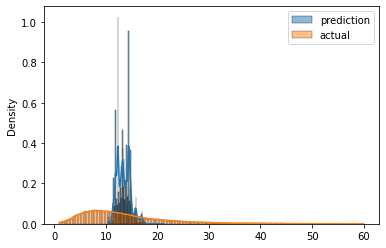

In [16]:
sns.histplot(y_pred, label='prediction', kde=True, stat='density', alpha=0.5)
sns.histplot(y_train, label='actual', kde=True, stat='density', alpha=0.5)

plt.legend()

In [17]:
def read_dataframe(filename):
    if filename.endswith('.csv'):
        df = pd.read_csv(filename)

        df.lpep_dropoff_datetime = pd.to_datetime(df.lpep_dropoff_datetime)
        df.lpep_pickup_datetime = pd.to_datetime(df.lpep_pickup_datetime)
    elif filename.endswith('.parquet'):
        df = pd.read_parquet(filename)

    df['duration'] = df.lpep_dropoff_datetime - df.lpep_pickup_datetime
    df.duration = df.duration.apply(lambda td: td.total_seconds() / 60)

    df = df[(df.duration >= 1) & (df.duration <= 60)]

    categorical = ['PULocationID', 'DOLocationID']
    df[categorical] = df[categorical].astype(str)
    
    return df

Training and Validation:

In [18]:
df_train = read_dataframe('https://d37ci6vzurychx.cloudfront.net/trip-data/green_tripdata_2025-01.parquet')
df_val = read_dataframe('https://d37ci6vzurychx.cloudfront.net/trip-data/green_tripdata_2025-02.parquet')

In [19]:
len(df_train), len(df_val)

(46307, 44218)

In [20]:
df_train['PU_DO'] = df_train['PULocationID'] + '_' + df_train['DOLocationID']
df_val['PU_DO'] = df_val['PULocationID'] + '_' + df_val['DOLocationID']

In [21]:
df_train['trip_type'] = df_train['trip_type'].astype(str)

In [22]:
categorical = ['PU_DO', 'trip_type'] #'PULocationID', 'DOLocationID']
numerical = ['trip_distance']

dv = DictVectorizer()

train_dicts = df_train[categorical + numerical].to_dict(orient='records')
X_train = dv.fit_transform(train_dicts)

val_dicts = df_val[categorical + numerical].to_dict(orient='records')
X_val = dv.transform(val_dicts)

In [23]:
target = 'duration'
y_train = df_train[target].values
y_val = df_val[target].values

Linear Regression:

In [24]:
lr = LinearRegression()
lr.fit(X_train, y_train)

y_pred = lr.predict(X_val)

root_mean_squared_error(y_val, y_pred)

6.154305820280958

Lasso:

In [25]:
ls = Lasso(0.1)
ls.fit(X_train, y_train)

y_pred = ls.predict(X_val)

root_mean_squared_error(y_val, y_pred)

9.03424026620296

In [26]:
#Lasso regressor gives the best rmse value
import os
os.makedirs('models', exist_ok=True)

with open('models/lin_reg.bin', 'wb') as f_out:
    pickle.dump((dv, ls), f_out)

Ridge:

In [27]:
r = Ridge(0.1)
r.fit(X_train, y_train)

y_pred = r.predict(X_val)

root_mean_squared_error(y_val, y_pred)

6.142132445649105

Starting experiments with Lasso:

In [28]:
with mlflow.start_run():

    mlflow.set_tag("developer", "kirthika")

    mlflow.log_param("train-data-path", "https://d37ci6vzurychx.cloudfront.net/trip-data/green_tripdata_2025-01.parquet")
    mlflow.log_param("valid-data-path", "https://d37ci6vzurychx.cloudfront.net/trip-data/green_tripdata_2025-02.parquet")

    alpha = 0.1
    mlflow.log_param("alpha", alpha)
    lr = Lasso(alpha)
    lr.fit(X_train, y_train)

    y_pred = lr.predict(X_val)
    rmse = root_mean_squared_error(y_val, y_pred)
    mlflow.log_metric("rmse", rmse)

Tracking this experiment with XGBoost, HyperOp using Linear Regression

In [29]:
import xgboost as xgb

from hyperopt import fmin, tpe, hp, STATUS_OK, Trials
from hyperopt.pyll import scope

In [33]:
train = xgb.DMatrix(X_train, label=y_train)
valid = xgb.DMatrix(X_val, label=y_val)

In [41]:
import sklearn
print(sklearn.__version__)  # you said 1.6.0

# verify the fix works
from sklearn.metrics import root_mean_squared_error
print(root_mean_squared_error(y_val, y_pred))  # should give ~5.x

1.6.0
9.03424026620296


In [42]:
def objective(params):
    with mlflow.start_run():
        mlflow.set_tag("model", "xgboost")
        mlflow.set_experiment("xgboost-hyperopt-tuning")
        mlflow.log_params(params)
        booster = xgb.train(
            params=params,
            dtrain=train,
            num_boost_round=1000,
            evals=[(valid, 'validation')],
            early_stopping_rounds=50
        )
        y_pred = booster.predict(valid)
        rmse = root_mean_squared_error(y_val, y_pred)
        mlflow.log_metric("rmse", rmse)

    return {'loss': rmse, 'status': STATUS_OK}

In [43]:
search_space = {
    'max_depth': scope.int(hp.quniform('max_depth', 4, 100, 1)),
    'learning_rate': hp.loguniform('learning_rate', -3, 0),
    'reg_alpha': hp.loguniform('reg_alpha', -5, -1),
    'reg_lambda': hp.loguniform('reg_lambda', -6, -1),
    'min_child_weight': hp.loguniform('min_child_weight', -1, 3),
    'objective': 'reg:linear',
    'seed': 42
}

best_result = fmin(
    fn=objective,
    space=search_space,
    algo=tpe.suggest,
    max_evals=50,
    trials=Trials()
)


  0%|                                                                                                   | 0/50 [00:00<?, ?trial/s, best loss=?]

2026/03/04 14:40:07 INFO mlflow.tracking.fluent: Experiment with name 'xgboost-hyperopt-tuning' does not exist. Creating a new experiment.



[0]	validation-rmse:8.28912                                                                                                                    
  0%|                                                                                                   | 0/50 [00:00<?, ?trial/s, best loss=?]

/home/codespace/anaconda3/lib/python3.9/site-packages/xgboost/core.py:158: UserWarning: [14:40:07] WARNING: /workspace/src/objective/regression_obj.cu:227: reg:linear is now deprecated in favor of reg:squarederror.
  warnings.warn(smsg, UserWarning)



[1]	validation-rmse:7.64794                                                                                                                    
[2]	validation-rmse:7.15556                                                                                                                    
[3]	validation-rmse:6.77901                                                                                                                    
[4]	validation-rmse:6.49503                                                                                                                    
[5]	validation-rmse:6.28108                                                                                                                    
[6]	validation-rmse:6.11672                                                                                                                    
[7]	validation-rmse:5.99865                                                                                                             

...

[560]	validation-rmse:5.42866                                                                                                                  
[561]	validation-rmse:5.42863                                                                                                                  
[562]	validation-rmse:5.42866                                                                                                                  
[563]	validation-rmse:5.42879                                                                                                                  
[564]	validation-rmse:5.42878                                                                                                                  
[565]	validation-rmse:5.42881                                                                                                                  
[566]	validation-rmse:5.42889                                                                                                           

/home/codespace/anaconda3/lib/python3.9/site-packages/xgboost/core.py:158: UserWarning: [15:02:32] WARNING: /workspace/src/objective/regression_obj.cu:227: reg:linear is now deprecated in favor of reg:squarederror.
  warnings.warn(smsg, UserWarning)



[0]	validation-rmse:6.92483                                                                                                                    
[1]	validation-rmse:6.03518                                                                                                                    
[2]	validation-rmse:5.74851                                                                                                                    
[3]	validation-rmse:5.65240                                                                                                                    
[4]	validation-rmse:5.61253                                                                                                                    
[5]	validation-rmse:5.60578                                                                                                                    
[6]	validation-rmse:5.60205                                                                                                             

/home/codespace/anaconda3/lib/python3.9/site-packages/xgboost/core.py:158: UserWarning: [15:02:46] WARNING: /workspace/src/objective/regression_obj.cu:227: reg:linear is now deprecated in favor of reg:squarederror.
  warnings.warn(smsg, UserWarning)



[0]	validation-rmse:6.64954                                                                                                                    
[1]	validation-rmse:5.93951                                                                                                                    
[2]	validation-rmse:5.74813                                                                                                                    
[3]	validation-rmse:5.67786                                                                                                                    
[4]	validation-rmse:5.63955                                                                                                                    
[5]	validation-rmse:5.63319                                                                                                                    
[6]	validation-rmse:5.61794                                                                                                             

## Select the best model based on the rmse, training time, size and run the same parameters with ML Flow autologging:

In [44]:
params = {
'learning_rate' : 0.2528037473043481,
'max_depth' : 5,
'min_child_weight' : 5.1810101322810915,
'objective' : 'reg:linear',
'reg_alpha' : 0.03263457245161076,
'reg_lambda': 0.04365512556253237,
'seed' : 42
}

mlflow.xgboost.autolog()

booster = xgb.train(
            params=params,
            dtrain=train,
            num_boost_round=1000,
            evals=[(valid, 'validation')],
            early_stopping_rounds=50
        )

2026/03/04 15:09:03 INFO mlflow.utils.autologging_utils: Created MLflow autologging run with ID 'de847d0bb5564f97819c836e8cf55568', which will track hyperparameters, performance metrics, model artifacts, and lineage information for the current xgboost workflow


[0]	validation-rmse:7.84337
[1]	validation-rmse:7.01899
[2]	validation-rmse:6.51211
[3]	validation-rmse:6.20772
[4]	validation-rmse:6.00776
[5]	validation-rmse:5.88517
[6]	validation-rmse:5.80441
[7]	validation-rmse:5.75003


/home/codespace/anaconda3/lib/python3.9/site-packages/xgboost/core.py:158: UserWarning: [15:09:04] WARNING: /workspace/src/objective/regression_obj.cu:227: reg:linear is now deprecated in favor of reg:squarederror.
  warnings.warn(smsg, UserWarning)


[8]	validation-rmse:5.71344
[9]	validation-rmse:5.69572
[10]	validation-rmse:5.68032
[11]	validation-rmse:5.66770
[12]	validation-rmse:5.65845
[13]	validation-rmse:5.65265
[14]	validation-rmse:5.64907
[15]	validation-rmse:5.64607
[16]	validation-rmse:5.64327
[17]	validation-rmse:5.63765
[18]	validation-rmse:5.63369
[19]	validation-rmse:5.63060
[20]	validation-rmse:5.62915
[21]	validation-rmse:5.62633
[22]	validation-rmse:5.62296
[23]	validation-rmse:5.62104
[24]	validation-rmse:5.61913
[25]	validation-rmse:5.61648
[26]	validation-rmse:5.61325
[27]	validation-rmse:5.60873
[28]	validation-rmse:5.60571
[29]	validation-rmse:5.60511
[30]	validation-rmse:5.60194
[31]	validation-rmse:5.60006
[32]	validation-rmse:5.59814
[33]	validation-rmse:5.59653
[34]	validation-rmse:5.59457
[35]	validation-rmse:5.59350
[36]	validation-rmse:5.58713
[37]	validation-rmse:5.58538
[38]	validation-rmse:5.58341
[39]	validation-rmse:5.58223
[40]	validation-rmse:5.58094
[41]	validation-rmse:5.57909
[42]	validation-

[285]	validation-rmse:5.40915
[286]	validation-rmse:5.40845
[287]	validation-rmse:5.40851
[288]	validation-rmse:5.40883
[289]	validation-rmse:5.40905
[290]	validation-rmse:5.40907
[291]	validation-rmse:5.40891
[292]	validation-rmse:5.40875
[293]	validation-rmse:5.40859
[294]	validation-rmse:5.40849
[295]	validation-rmse:5.40848
[296]	validation-rmse:5.40840
[297]	validation-rmse:5.40830
[298]	validation-rmse:5.40811
[299]	validation-rmse:5.40805
[300]	validation-rmse:5.40795
[301]	validation-rmse:5.40779
[302]	validation-rmse:5.40768
[303]	validation-rmse:5.40775
[304]	validation-rmse:5.40764
[305]	validation-rmse:5.40748
[306]	validation-rmse:5.40729
[307]	validation-rmse:5.40712
[308]	validation-rmse:5.40723
[309]	validation-rmse:5.40706
[310]	validation-rmse:5.40695
[311]	validation-rmse:5.40662
[312]	validation-rmse:5.40636
[313]	validation-rmse:5.40589
[314]	validation-rmse:5.40574
[315]	validation-rmse:5.40539
[316]	validation-rmse:5.40506
[317]	validation-rmse:5.40468
[318]	vali

[559]	validation-rmse:5.37010
[560]	validation-rmse:5.36938
[561]	validation-rmse:5.36947
[562]	validation-rmse:5.36962
[563]	validation-rmse:5.36942
[564]	validation-rmse:5.36940
[565]	validation-rmse:5.36942
[566]	validation-rmse:5.36953
[567]	validation-rmse:5.36944
[568]	validation-rmse:5.36945
[569]	validation-rmse:5.36953
[570]	validation-rmse:5.36842
[571]	validation-rmse:5.36805
[572]	validation-rmse:5.36795
[573]	validation-rmse:5.36786
[574]	validation-rmse:5.36784
[575]	validation-rmse:5.36814
[576]	validation-rmse:5.36800
[577]	validation-rmse:5.36784
[578]	validation-rmse:5.36737
[579]	validation-rmse:5.36719
[580]	validation-rmse:5.36719
[581]	validation-rmse:5.36723
[582]	validation-rmse:5.36717
[583]	validation-rmse:5.36716
[584]	validation-rmse:5.36719
[585]	validation-rmse:5.36655
[586]	validation-rmse:5.36665
[587]	validation-rmse:5.36668
[588]	validation-rmse:5.36678
[589]	validation-rmse:5.36688
[590]	validation-rmse:5.36694
[591]	validation-rmse:5.36699
[592]	vali

[833]	validation-rmse:5.34486
[834]	validation-rmse:5.34489
[835]	validation-rmse:5.34489
[836]	validation-rmse:5.34453
[837]	validation-rmse:5.34447
[838]	validation-rmse:5.34444
[839]	validation-rmse:5.34444
[840]	validation-rmse:5.34439
[841]	validation-rmse:5.34442
[842]	validation-rmse:5.34442
[843]	validation-rmse:5.34443
[844]	validation-rmse:5.34438
[845]	validation-rmse:5.34422
[846]	validation-rmse:5.34431
[847]	validation-rmse:5.34435
[848]	validation-rmse:5.34438
[849]	validation-rmse:5.34426
[850]	validation-rmse:5.34424
[851]	validation-rmse:5.34404
[852]	validation-rmse:5.34386
[853]	validation-rmse:5.34396
[854]	validation-rmse:5.34403
[855]	validation-rmse:5.34405
[856]	validation-rmse:5.34380
[857]	validation-rmse:5.34381
[858]	validation-rmse:5.34383
[859]	validation-rmse:5.34381
[860]	validation-rmse:5.34373
[861]	validation-rmse:5.34360
[862]	validation-rmse:5.34368
[863]	validation-rmse:5.34367
[864]	validation-rmse:5.34383
[865]	validation-rmse:5.34376
[866]	vali

2026/03/04 15:09:29 WARNING mlflow.xgboost: Failed to infer model signature: could not sample data to infer model signature: please ensure that autologging is enabled before constructing the dataset.
2026/03/04 15:09:29 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/03/04 15:09:29 WARNING mlflow.utils.autologging_utils: MLflow autologging encountered a warning: "/home/codespace/anaconda3/lib/python3.9/site-packages/xgboost/core.py:158: UserWarning: [15:09:29] WARNING: /workspace/src/c_api/c_api.cc:1374: Saving model in the UBJSON format as default.  You can use file extension: `json`, `ubj` or `deprecated` to choose between formats."
2026/03/04 15:09:42 WARNING mlflow.utils.environment: Encountered an unexpected error while inferring pip requirements (model URI: /tmp/tmpvj6ezu0o/model, flavor: xgboost). Fall back to return ['xgboost==2.1.4']. Set logging level to DEBUG to see the full traceback. 
2026/03/04 15:09:42 WARNING mlflow.models.mod

Saving the model by logging - Way 1:

In [31]:
with mlflow.start_run():

    mlflow.set_tag("developer", "kirthika")

    mlflow.log_param("train-data-path", "https://d37ci6vzurychx.cloudfront.net/trip-data/green_tripdata_2025-01.parquet")
    mlflow.log_param("valid-data-path", "https://d37ci6vzurychx.cloudfront.net/trip-data/green_tripdata_2025-02.parquet")

    alpha = 0.1
    mlflow.log_param("alpha", alpha)
    lr = Lasso(alpha)
    lr.fit(X_train, y_train)

    y_pred = lr.predict(X_val)
    rmse = root_mean_squared_error(y_val, y_pred)
    mlflow.log_metric("rmse", rmse)
    
    mlflow.log_artifact(local_path="models/lin_reg.bin", artifact_path="models_pickle")

Saving the model by logging - Way 2:

In [36]:
with mlflow.start_run():
    params = {
    'learning_rate' : 0.2528037473043481,
    'max_depth' : 5,
    'min_child_weight' : 5.1810101322810915,
    'objective' : 'reg:linear',
    'reg_alpha' : 0.03263457245161076,
    'reg_lambda': 0.04365512556253237,
    'seed' : 42
    }
    mlflow.log_params(params)


    booster = xgb.train(
                params=params,
                dtrain=train,
                num_boost_round=1000,
                evals=[(valid, 'validation')],
                early_stopping_rounds=50
            )
    y_pred = booster.predict(valid)
    rmse = mean_squared_error(y_val, y_pred)
    mlflow.log_metric("rmse", rmse)
    
    mlflow.xgboost.log_model(booster, name="models_mlflow")

[0]	validation-rmse:7.84337
[1]	validation-rmse:7.01899
[2]	validation-rmse:6.51211
[3]	validation-rmse:6.20772
[4]	validation-rmse:6.00776
[5]	validation-rmse:5.88517
[6]	validation-rmse:5.80441
[7]	validation-rmse:5.75003


/home/codespace/anaconda3/lib/python3.9/site-packages/xgboost/core.py:158: UserWarning: [06:42:48] WARNING: /workspace/src/objective/regression_obj.cu:227: reg:linear is now deprecated in favor of reg:squarederror.
  warnings.warn(smsg, UserWarning)


[8]	validation-rmse:5.71344
[9]	validation-rmse:5.69572
[10]	validation-rmse:5.68032
[11]	validation-rmse:5.66770
[12]	validation-rmse:5.65845
[13]	validation-rmse:5.65265
[14]	validation-rmse:5.64907
[15]	validation-rmse:5.64607
[16]	validation-rmse:5.64327
[17]	validation-rmse:5.63765
[18]	validation-rmse:5.63369
[19]	validation-rmse:5.63060
[20]	validation-rmse:5.62915
[21]	validation-rmse:5.62633
[22]	validation-rmse:5.62296
[23]	validation-rmse:5.62104
[24]	validation-rmse:5.61913
[25]	validation-rmse:5.61648
[26]	validation-rmse:5.61325
[27]	validation-rmse:5.60873
[28]	validation-rmse:5.60571
[29]	validation-rmse:5.60511
[30]	validation-rmse:5.60194
[31]	validation-rmse:5.60006
[32]	validation-rmse:5.59814
[33]	validation-rmse:5.59653
[34]	validation-rmse:5.59457
[35]	validation-rmse:5.59350
[36]	validation-rmse:5.58713
[37]	validation-rmse:5.58538
[38]	validation-rmse:5.58341
[39]	validation-rmse:5.58223
[40]	validation-rmse:5.58094
[41]	validation-rmse:5.57909
[42]	validation-

[285]	validation-rmse:5.40915
[286]	validation-rmse:5.40845
[287]	validation-rmse:5.40851
[288]	validation-rmse:5.40883
[289]	validation-rmse:5.40905
[290]	validation-rmse:5.40907
[291]	validation-rmse:5.40891
[292]	validation-rmse:5.40875
[293]	validation-rmse:5.40859
[294]	validation-rmse:5.40849
[295]	validation-rmse:5.40848
[296]	validation-rmse:5.40840
[297]	validation-rmse:5.40830
[298]	validation-rmse:5.40811
[299]	validation-rmse:5.40805
[300]	validation-rmse:5.40795
[301]	validation-rmse:5.40779
[302]	validation-rmse:5.40768
[303]	validation-rmse:5.40775
[304]	validation-rmse:5.40764
[305]	validation-rmse:5.40748
[306]	validation-rmse:5.40729
[307]	validation-rmse:5.40712
[308]	validation-rmse:5.40723
[309]	validation-rmse:5.40706
[310]	validation-rmse:5.40695
[311]	validation-rmse:5.40662
[312]	validation-rmse:5.40636
[313]	validation-rmse:5.40589
[314]	validation-rmse:5.40574
[315]	validation-rmse:5.40539
[316]	validation-rmse:5.40506
[317]	validation-rmse:5.40468
[318]	vali

[559]	validation-rmse:5.37010
[560]	validation-rmse:5.36938
[561]	validation-rmse:5.36947
[562]	validation-rmse:5.36962
[563]	validation-rmse:5.36942
[564]	validation-rmse:5.36940
[565]	validation-rmse:5.36942
[566]	validation-rmse:5.36953
[567]	validation-rmse:5.36944
[568]	validation-rmse:5.36945
[569]	validation-rmse:5.36953
[570]	validation-rmse:5.36842
[571]	validation-rmse:5.36805
[572]	validation-rmse:5.36795
[573]	validation-rmse:5.36786
[574]	validation-rmse:5.36784
[575]	validation-rmse:5.36814
[576]	validation-rmse:5.36800
[577]	validation-rmse:5.36784
[578]	validation-rmse:5.36737
[579]	validation-rmse:5.36719
[580]	validation-rmse:5.36719
[581]	validation-rmse:5.36723
[582]	validation-rmse:5.36717
[583]	validation-rmse:5.36716
[584]	validation-rmse:5.36719
[585]	validation-rmse:5.36655
[586]	validation-rmse:5.36665
[587]	validation-rmse:5.36668
[588]	validation-rmse:5.36678
[589]	validation-rmse:5.36688
[590]	validation-rmse:5.36694
[591]	validation-rmse:5.36699
[592]	vali

[833]	validation-rmse:5.34486
[834]	validation-rmse:5.34489
[835]	validation-rmse:5.34489
[836]	validation-rmse:5.34453
[837]	validation-rmse:5.34447
[838]	validation-rmse:5.34444
[839]	validation-rmse:5.34444
[840]	validation-rmse:5.34439
[841]	validation-rmse:5.34442
[842]	validation-rmse:5.34442
[843]	validation-rmse:5.34443
[844]	validation-rmse:5.34438
[845]	validation-rmse:5.34422
[846]	validation-rmse:5.34431
[847]	validation-rmse:5.34435
[848]	validation-rmse:5.34438
[849]	validation-rmse:5.34426
[850]	validation-rmse:5.34424
[851]	validation-rmse:5.34404
[852]	validation-rmse:5.34386
[853]	validation-rmse:5.34396
[854]	validation-rmse:5.34403
[855]	validation-rmse:5.34405
[856]	validation-rmse:5.34380
[857]	validation-rmse:5.34381
[858]	validation-rmse:5.34383
[859]	validation-rmse:5.34381
[860]	validation-rmse:5.34373
[861]	validation-rmse:5.34360
[862]	validation-rmse:5.34368
[863]	validation-rmse:5.34367
[864]	validation-rmse:5.34383
[865]	validation-rmse:5.34376
[866]	vali

/home/codespace/anaconda3/lib/python3.9/site-packages/xgboost/core.py:158: UserWarning: [06:43:10] WARNING: /workspace/src/c_api/c_api.cc:1374: Saving model in the UBJSON format as default.  You can use file extension: `json`, `ubj` or `deprecated` to choose between formats.
  warnings.warn(smsg, UserWarning)
2026/03/07 06:43:14 WARNING mlflow.utils.environment: Encountered an unexpected error while inferring pip requirements (model URI: /tmp/tmpxugveqs2/model, flavor: xgboost). Fall back to return ['xgboost==2.1.4']. Set logging level to DEBUG to see the full traceback. 
2026/03/07 06:43:14 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


Saving preprocessor - DictVectorizer:

In [37]:
with open("models/preprocessor.b", "wb") as f_out:
    pickle.dump(dv, f_out)

In [41]:
with mlflow.start_run():
    params = {
    'learning_rate' : 0.2528037473043481,
    'max_depth' : 5,
    'min_child_weight' : 5.1810101322810915,
    'objective' : 'reg:linear',
    'reg_alpha' : 0.03263457245161076,
    'reg_lambda': 0.04365512556253237,
    'seed' : 42
    }
    mlflow.log_params(params)


    booster = xgb.train(
                params=params,
                dtrain=train,
                num_boost_round=1000,
                evals=[(valid, 'validation')],
                early_stopping_rounds=50
            )
    y_pred = booster.predict(valid)
    rmse = mean_squared_error(y_val, y_pred)
    mlflow.log_metric("rmse", rmse)
    
    mlflow.log_artifact("models/preprocessor.b", artifact_path="preprocessor")
    mlflow.xgboost.log_model(booster, name="models_mlflow")

[0]	validation-rmse:7.84337
[1]	validation-rmse:7.01899
[2]	validation-rmse:6.51211
[3]	validation-rmse:6.20772
[4]	validation-rmse:6.00776
[5]	validation-rmse:5.88517
[6]	validation-rmse:5.80441
[7]	validation-rmse:5.75003


/home/codespace/anaconda3/lib/python3.9/site-packages/xgboost/core.py:158: UserWarning: [07:00:40] WARNING: /workspace/src/objective/regression_obj.cu:227: reg:linear is now deprecated in favor of reg:squarederror.
  warnings.warn(smsg, UserWarning)


[8]	validation-rmse:5.71344
[9]	validation-rmse:5.69572
[10]	validation-rmse:5.68032
[11]	validation-rmse:5.66770
[12]	validation-rmse:5.65845
[13]	validation-rmse:5.65265
[14]	validation-rmse:5.64907
[15]	validation-rmse:5.64607
[16]	validation-rmse:5.64327
[17]	validation-rmse:5.63765
[18]	validation-rmse:5.63369
[19]	validation-rmse:5.63060
[20]	validation-rmse:5.62915
[21]	validation-rmse:5.62633
[22]	validation-rmse:5.62296
[23]	validation-rmse:5.62104
[24]	validation-rmse:5.61913
[25]	validation-rmse:5.61648
[26]	validation-rmse:5.61325
[27]	validation-rmse:5.60873
[28]	validation-rmse:5.60571
[29]	validation-rmse:5.60511
[30]	validation-rmse:5.60194
[31]	validation-rmse:5.60006
[32]	validation-rmse:5.59814
[33]	validation-rmse:5.59653
[34]	validation-rmse:5.59457
[35]	validation-rmse:5.59350
[36]	validation-rmse:5.58713
[37]	validation-rmse:5.58538
[38]	validation-rmse:5.58341
[39]	validation-rmse:5.58223
[40]	validation-rmse:5.58094
[41]	validation-rmse:5.57909
[42]	validation-

[285]	validation-rmse:5.40915
[286]	validation-rmse:5.40845
[287]	validation-rmse:5.40851
[288]	validation-rmse:5.40883
[289]	validation-rmse:5.40905
[290]	validation-rmse:5.40907
[291]	validation-rmse:5.40891
[292]	validation-rmse:5.40875
[293]	validation-rmse:5.40859
[294]	validation-rmse:5.40849
[295]	validation-rmse:5.40848
[296]	validation-rmse:5.40840
[297]	validation-rmse:5.40830
[298]	validation-rmse:5.40811
[299]	validation-rmse:5.40805
[300]	validation-rmse:5.40795
[301]	validation-rmse:5.40779
[302]	validation-rmse:5.40768
[303]	validation-rmse:5.40775
[304]	validation-rmse:5.40764
[305]	validation-rmse:5.40748
[306]	validation-rmse:5.40729
[307]	validation-rmse:5.40712
[308]	validation-rmse:5.40723
[309]	validation-rmse:5.40706
[310]	validation-rmse:5.40695
[311]	validation-rmse:5.40662
[312]	validation-rmse:5.40636
[313]	validation-rmse:5.40589
[314]	validation-rmse:5.40574
[315]	validation-rmse:5.40539
[316]	validation-rmse:5.40506
[317]	validation-rmse:5.40468
[318]	vali

[559]	validation-rmse:5.37010
[560]	validation-rmse:5.36938
[561]	validation-rmse:5.36947
[562]	validation-rmse:5.36962
[563]	validation-rmse:5.36942
[564]	validation-rmse:5.36940
[565]	validation-rmse:5.36942
[566]	validation-rmse:5.36953
[567]	validation-rmse:5.36944
[568]	validation-rmse:5.36945
[569]	validation-rmse:5.36953
[570]	validation-rmse:5.36842
[571]	validation-rmse:5.36805
[572]	validation-rmse:5.36795
[573]	validation-rmse:5.36786
[574]	validation-rmse:5.36784
[575]	validation-rmse:5.36814
[576]	validation-rmse:5.36800
[577]	validation-rmse:5.36784
[578]	validation-rmse:5.36737
[579]	validation-rmse:5.36719
[580]	validation-rmse:5.36719
[581]	validation-rmse:5.36723
[582]	validation-rmse:5.36717
[583]	validation-rmse:5.36716
[584]	validation-rmse:5.36719
[585]	validation-rmse:5.36655
[586]	validation-rmse:5.36665
[587]	validation-rmse:5.36668
[588]	validation-rmse:5.36678
[589]	validation-rmse:5.36688
[590]	validation-rmse:5.36694
[591]	validation-rmse:5.36699
[592]	vali

[839]	validation-rmse:5.34444
[840]	validation-rmse:5.34439
[841]	validation-rmse:5.34442
[842]	validation-rmse:5.34442
[843]	validation-rmse:5.34443
[844]	validation-rmse:5.34438
[845]	validation-rmse:5.34422
[846]	validation-rmse:5.34431
[847]	validation-rmse:5.34435
[848]	validation-rmse:5.34438
[849]	validation-rmse:5.34426
[850]	validation-rmse:5.34424
[851]	validation-rmse:5.34404
[852]	validation-rmse:5.34386
[853]	validation-rmse:5.34396
[854]	validation-rmse:5.34403
[855]	validation-rmse:5.34405
[856]	validation-rmse:5.34380
[857]	validation-rmse:5.34381
[858]	validation-rmse:5.34383
[859]	validation-rmse:5.34381
[860]	validation-rmse:5.34373
[861]	validation-rmse:5.34360
[862]	validation-rmse:5.34368
[863]	validation-rmse:5.34367
[864]	validation-rmse:5.34383
[865]	validation-rmse:5.34376
[866]	validation-rmse:5.34375
[867]	validation-rmse:5.34370
[868]	validation-rmse:5.34370
[869]	validation-rmse:5.34371
[870]	validation-rmse:5.34377
[871]	validation-rmse:5.34366
[872]	vali

/home/codespace/anaconda3/lib/python3.9/site-packages/xgboost/core.py:158: UserWarning: [07:01:02] WARNING: /workspace/src/c_api/c_api.cc:1374: Saving model in the UBJSON format as default.  You can use file extension: `json`, `ubj` or `deprecated` to choose between formats.
  warnings.warn(smsg, UserWarning)
2026/03/07 07:01:06 WARNING mlflow.utils.environment: Encountered an unexpected error while inferring pip requirements (model URI: /tmp/tmpbz803x74/model, flavor: xgboost). Fall back to return ['xgboost==2.1.4']. Set logging level to DEBUG to see the full traceback. 
2026/03/07 07:01:06 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.
